# Datos Faltantes

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.impute import SimpleImputer, KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar el conjunto de datos
diabetes = load_diabetes(as_frame=True)
data = diabetes.data
data['target'] = diabetes.target

In [3]:
data.sample(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
174,0.016281,0.050680,0.009961,-0.043542,-0.096510,-0.094632,-0.039719,-0.039493,0.017036,0.007207,151.0
130,-0.063635,0.050680,0.096186,0.104501,-0.002945,-0.004759,-0.006584,-0.002592,0.022688,0.073480,274.0
253,0.081666,-0.044642,0.033673,0.008101,0.052093,0.056619,-0.017629,0.034309,0.034866,0.069338,150.0
178,0.041708,-0.044642,-0.008362,-0.026328,0.024574,0.016222,0.070730,-0.039493,-0.048359,-0.030072,81.0
104,-0.027310,-0.044642,0.064930,-0.002228,-0.024960,-0.017284,0.022869,-0.039493,-0.061176,-0.063209,95.0
197,0.048974,0.050680,0.003494,0.070072,-0.008449,0.013404,-0.054446,0.034309,0.013317,0.036201,129.0
260,0.041708,-0.044642,-0.008362,-0.057313,0.008063,-0.031376,0.151726,-0.076395,-0.080237,-0.017646,39.0
416,-0.027310,-0.044642,0.080019,0.098751,-0.002945,0.018101,-0.017629,0.003312,-0.029526,0.036201,257.0
331,0.081666,0.050680,-0.025607,-0.036656,-0.070367,-0.046407,-0.039719,-0.002592,-0.041176,-0.005220,199.0
420,0.023546,-0.044642,-0.036385,0.000079,0.001183,0.034698,-0.043401,0.034309,-0.033246,0.061054,146.0


In [4]:
# Simular valores faltantes
np.random.seed(42)
data.loc[data.sample(frac=0.1).index, 'bmi'] = np.nan
data.loc[data.sample(frac=0.1).index, 'bp'] = np.nan

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado:

### 1. ¿Cuántos valores faltantes hay en cada columna?**

In [5]:
data.isna().sum()
bmi_original = data['bmi'].copy()

### 2. Utiliza imputación simple (media) para llenar los valores faltantes de la columna 'bmi'.

In [6]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
data['bmi'] = imputer.fit_transform(data[['bmi']])

### 3. Utiliza KNNImputer para imputar valores en las columnas 'bmi' y 'bp'. Compara los resultados con los de la imputación simple.

In [7]:
from sklearn.impute import KNNImputer

knn = KNNImputer(n_neighbors=5)
data[['bmi', 'bp']] = knn.fit_transform(data[['bmi', 'bp']])

### 4. Genera un histograma comparando los datos antes y después de la imputación en la columna 'bmi'.

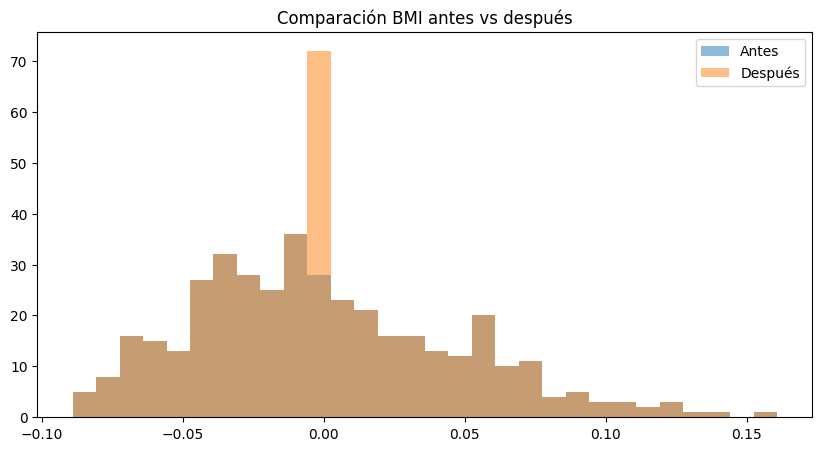

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(bmi_original.dropna(), bins=30, alpha=0.5, label='Antes')
plt.hist(data['bmi'], bins=30, alpha=0.5, label='Después')

plt.legend()
plt.title('Comparación BMI antes vs después')
plt.show()